In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('employees.csv')
data.head()

,Age,Salary,Department,Experience,Performance,Promoted
0,25,40000.0,HR,2.0,Good,No
1,32,60000.0,IT,5.0,Excellent,Yes
2,45,NaN,Finance,10.0,Good,Yes
3,28,50000.0,IT,3.0,Average,No
4,40,90000.0,Finance,NaN,Excellent,Yes


In [3]:
# data = data.dropna()
# data

In [4]:
data.isna().sum()

Age            0
Salary         2
Department     0
Experience     1
Performance    0
Promoted       0
dtype: int64

In [5]:
data.fillna(data.mean(numeric_only=True),inplace=True)

,Age,Salary,Department,Experience,Performance,Promoted
0,25,40000.0,HR,2.000000,Good,No
1,32,60000.0,IT,5.000000,Excellent,Yes
2,45,63125.0,Finance,10.000000,Good,Yes
3,28,50000.0,IT,3.000000,Average,No
4,40,90000.0,Finance,5.555556,Excellent,Yes
5,35,55000.0,HR,4.000000,Good,No
6,29,48000.0,Marketing,3.000000,Average,No
7,50,120000.0,Finance,15.000000,Excellent,Yes
8,31,63125.0,IT,6.000000,Good,Yes
9,27,42000.0,Marketing,2.000000,Average,No


In [6]:
# convert performance col to numeric
le = LabelEncoder()

# data['Performance'] = le.fit_transform(data['Performance'])
# data['Department'] = le.fit_transform(data['Department'])
# data['Promoted'] = le.fit_transform(data['Promoted'])

for col in data.select_dtypes(include='object'):
    data[col] = le.fit_transform(data[col])

data

/var/folders/st/__3x87v14fq9j0yf8dz_w3mr0000gn/T/ipykernel_55704/4223340305.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object'):


,Age,Salary,Department,Experience,Performance,Promoted
0,25,40000.0,1,2.000000,2,0
1,32,60000.0,2,5.000000,1,1
2,45,63125.0,0,10.000000,2,1
3,28,50000.0,2,3.000000,0,0
4,40,90000.0,0,5.555556,1,1
5,35,55000.0,1,4.000000,2,0
6,29,48000.0,3,3.000000,0,0
7,50,120000.0,0,15.000000,1,1
8,31,63125.0,2,6.000000,2,1
9,27,42000.0,3,2.000000,0,0


In [7]:
X = data.iloc[:,:-1]
X

,Age,Salary,Department,Experience,Performance
0,25,40000.0,1,2.000000,2
1,32,60000.0,2,5.000000,1
2,45,63125.0,0,10.000000,2
3,28,50000.0,2,3.000000,0
4,40,90000.0,0,5.555556,1
5,35,55000.0,1,4.000000,2
6,29,48000.0,3,3.000000,0
7,50,120000.0,0,15.000000,1
8,31,63125.0,2,6.000000,2
9,27,42000.0,3,2.000000,0


In [8]:
y = data.iloc[:,-1]
y

0    0
1    1
2    1
3    0
4    1
5    0
6    0
7    1
8    1
9    0
Name: Promoted, dtype: int64

In [9]:
X_train , X_test , y_train , y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

# Train model
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]


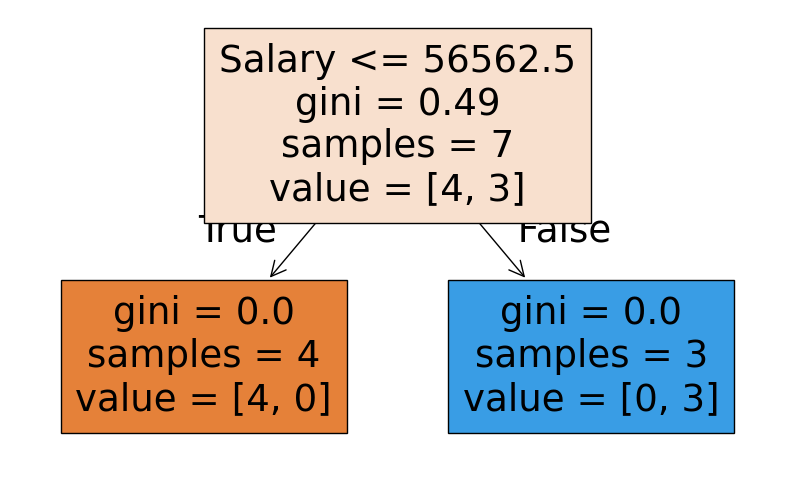

In [10]:
plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [21]:
X

,Age,Salary,Department,Experience,Performance
0,25,40000.0,1,2.000000,2
1,32,60000.0,2,5.000000,1
2,45,63125.0,0,10.000000,2
3,28,50000.0,2,3.000000,0
4,40,90000.0,0,5.555556,1
5,35,55000.0,1,4.000000,2
6,29,48000.0,3,3.000000,0
7,50,120000.0,0,15.000000,1
8,31,63125.0,2,6.000000,2
9,27,42000.0,3,2.000000,0


In [18]:
X.iloc[:,1]

0     40000.0
1     60000.0
2     63125.0
3     50000.0
4     90000.0
5     55000.0
6     48000.0
7    120000.0
8     63125.0
9     42000.0
Name: Salary, dtype: float64

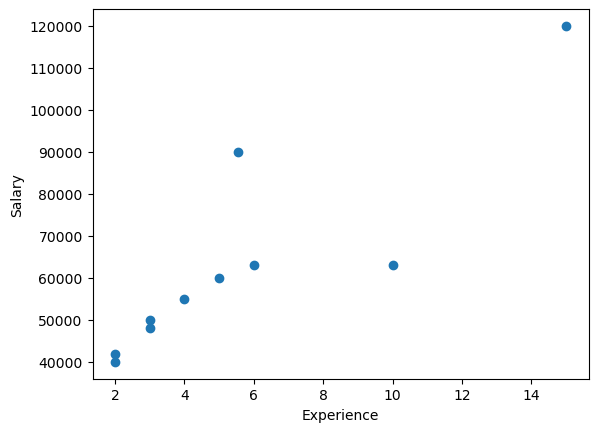

In [25]:
plt.scatter(X.iloc[:,3],X.iloc[:,1])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

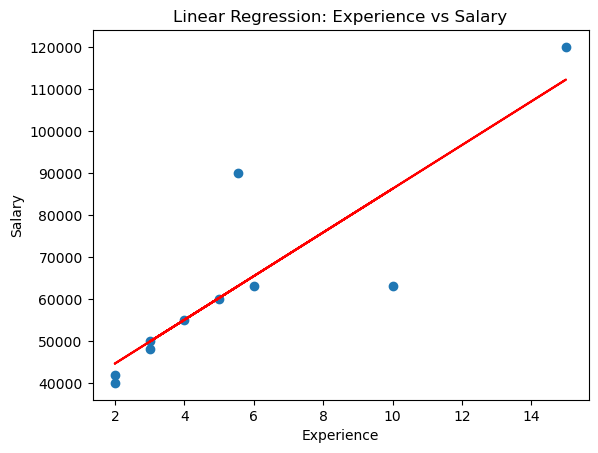

In [26]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Experience as input
x = X.iloc[:, [3]]   # keep as 2D
y = X.iloc[:, 1]     # Salary

# Train model
model = LinearRegression()
model.fit(x, y)

# Predict line values
y_pred = model.predict(x)

# Plot
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")
plt.show()

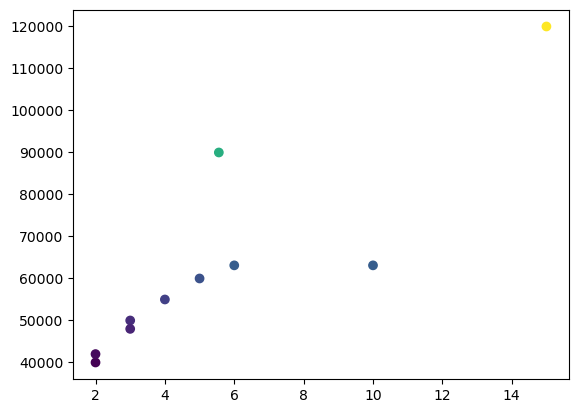

In [28]:
plt.scatter(X.iloc[:,3], X.iloc[:,1], c=y)
plt.show()

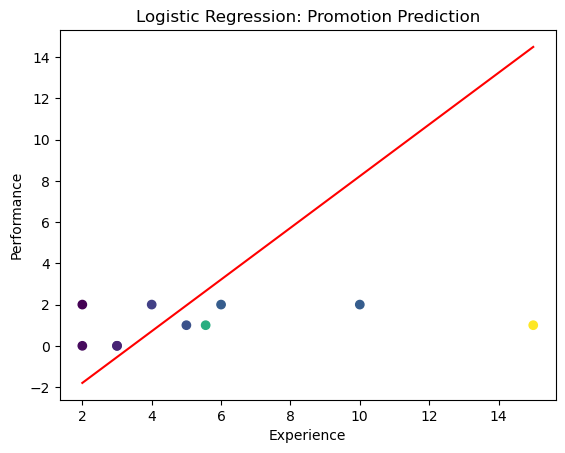

In [30]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Experience + Performance
x = X.iloc[:, [3,4]]
target = y

# Train model
model = LogisticRegression()
model.fit(x, target)

# Scatter plot
plt.scatter(
    X.iloc[:,3],   # Experience
    X.iloc[:,4],   # Performance
    c=target
)

# Decision boundary
x_line = np.linspace(X.iloc[:,3].min(), X.iloc[:,3].max(), 100)
y_line = -(model.coef_[0][0]*x_line + model.intercept_[0]) / model.coef_[0][1]

plt.plot(x_line, y_line, color='red')

plt.xlabel("Experience")
plt.ylabel("Performance")
plt.title("Logistic Regression: Promotion Prediction")
plt.show()